# Realized & range-based volatility — `qufin`

Volatility is unobservable; we only ever *estimate* it. The classical
close-to-close estimator throws away most of the trading day. This notebook
covers two families of sharper estimators and a simple, strong forecasting
model:

* **Range-based** (`qufin.indicators`) — use the open/high/low/close of each
  bar: Parkinson, Garman-Klass, Rogers-Satchell, Yang-Zhang. Far more
  efficient than close-to-close from the *same* daily data.
* **Realized** (`qufin.timeseries.realized`) — sum squared *intraday* returns
  to estimate integrated variance; bipower variation isolates the jump part.
* **HAR-RV** (`qufin.timeseries.HARRV`) — Corsi's (2009) cascade of
  daily/weekly/monthly realized variance, a benchmark-beating volatility
  forecaster that complements the GARCH family in `qufin.timeseries.garch`.

**Sections**

0. OHLC data (real, with synthetic fallback)
1. Range-based estimators & their efficiency
2. Realized variance from intraday returns
3. Bipower variation & jump detection
4. HAR-RV forecasting


## Why range and realized estimators win

The close-to-close estimator uses one number per day (the return), so its
sampling error is large. Two ways to do better with the *same or finer* data:

* A day's **high-low range** already reveals how much price travelled —
  Parkinson (1980) showed the range is ~5× more efficient than the squared
  return. Garman-Klass, Rogers-Satchell and Yang-Zhang progressively add the
  open-close move, drift-robustness, and overnight gaps.
* If you have **intraday** prices, the sum of squared 5-minute returns
  (*realized variance*) converges to the true integrated variance as sampling
  frequency rises — a near-observable volatility, which is what makes HAR-RV
  possible.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qufin.indicators import parkinson, garman_klass, rogers_satchell, yang_zhang
from qufin.timeseries import (
    realized_variance, realized_volatility, bipower_variation, HARRV,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 0. OHLC data

Real daily OHLC if `yfinance` is reachable, otherwise a synthetic
stochastic-volatility series whose intraday path produces consistent OHLC
bars.


In [2]:
def load_ohlc(ticker='SPY', start='2015-01-01', end='2024-01-01'):
    try:
        import pandas as pd
        import yfinance as yf
        raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        raw = raw.dropna()
        if len(raw) > 800:
            return (raw['Open'].to_numpy('float64'), raw['High'].to_numpy('float64'),
                    raw['Low'].to_numpy('float64'), raw['Close'].to_numpy('float64'), ticker)
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); simulating OHLC')
    rng = np.random.default_rng(0)
    n, steps = 2000, 30
    log_vol = np.empty(n); log_vol[0] = np.log(0.01)
    for t in range(1, n):  # persistent stochastic volatility
        log_vol[t] = 0.99 * log_vol[t-1] + 0.01 * np.log(0.01) + rng.normal(0, 0.15)
    sig = np.exp(log_vol)
    o = np.empty(n); h = np.empty(n); low = np.empty(n); c = np.empty(n)
    price = 100.0
    for t in range(n):
        o[t] = price
        path = price * np.exp(np.cumsum(rng.normal(0, sig[t]/np.sqrt(steps), steps)))
        h[t] = max(path.max(), price); low[t] = min(path.min(), price); c[t] = path[-1]
        price = c[t]
    return o, h, low, c, 'synthetic SV'

o, h, low, c, label = load_ohlc()
print(f'{label}: {c.size} daily bars')


SPY: 2264 daily bars


## 1. Range-based estimators

Each returns a trailing-window **annualised** volatility. Compare them to the
naive close-to-close estimate over the same window — the range estimators are
markedly smoother (lower sampling error) for the same data.


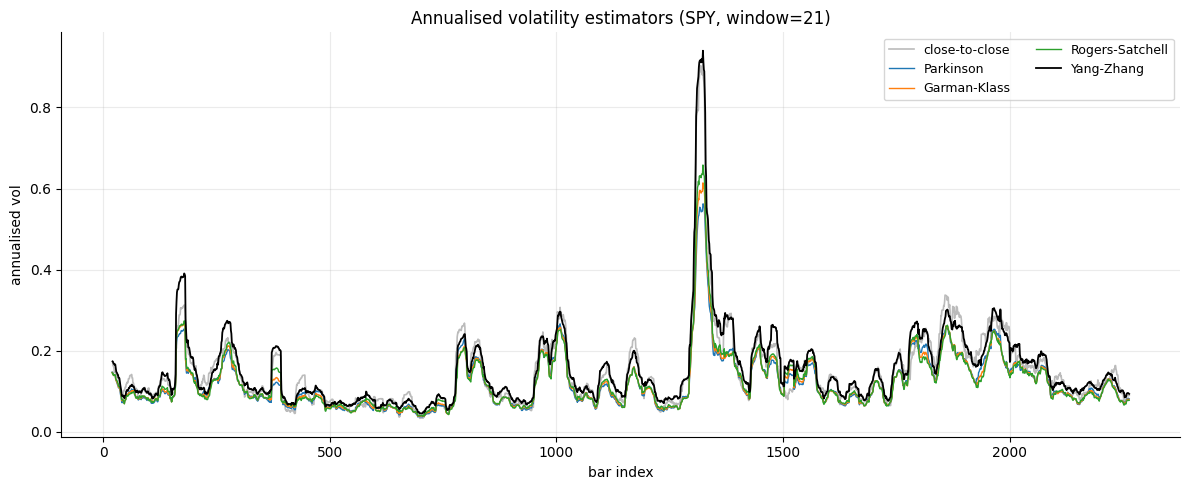

     close-close: mean=0.148  std=0.100
       Parkinson: mean=0.121  std=0.069
    Garman-Klass: mean=0.122  std=0.072
 Rogers-Satchell: mean=0.123  std=0.074
      Yang-Zhang: mean=0.154  std=0.103


In [3]:
win = 21
log_ret = np.diff(np.log(c))
cc = np.full(c.size, np.nan)
# Rolling close-to-close annualised vol.
for t in range(win, c.size):
    cc[t] = np.std(log_ret[t-win:t]) * np.sqrt(252)

pk = parkinson(h, low, window=win)
gk = garman_klass(o, h, low, c, window=win)
rs = rogers_satchell(o, h, low, c, window=win)
yz = yang_zhang(o, h, low, c, window=win)

fig, ax = plt.subplots()
ax.plot(cc, color='#bbb', lw=1.2, label='close-to-close')
ax.plot(pk, lw=1.0, label='Parkinson')
ax.plot(gk, lw=1.0, label='Garman-Klass')
ax.plot(rs, lw=1.0, label='Rogers-Satchell')
ax.plot(yz, lw=1.3, color='#000', label='Yang-Zhang')
ax.set_title(f'Annualised volatility estimators ({label}, window={win})')
ax.set_ylabel('annualised vol'); ax.set_xlabel('bar index'); ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

for name, est in [('close-close', cc), ('Parkinson', pk), ('Garman-Klass', gk),
                  ('Rogers-Satchell', rs), ('Yang-Zhang', yz)]:
    print(f'{name:>16}: mean={np.nanmean(est):.3f}  std={np.nanstd(est):.3f}')


## 2. Realized variance from intraday returns

With intraday returns, `realized_variance` sums their squares to estimate the
day's integrated variance. Here we simulate one day of 5-minute returns and
show how the estimate stabilises as more of the day is observed.


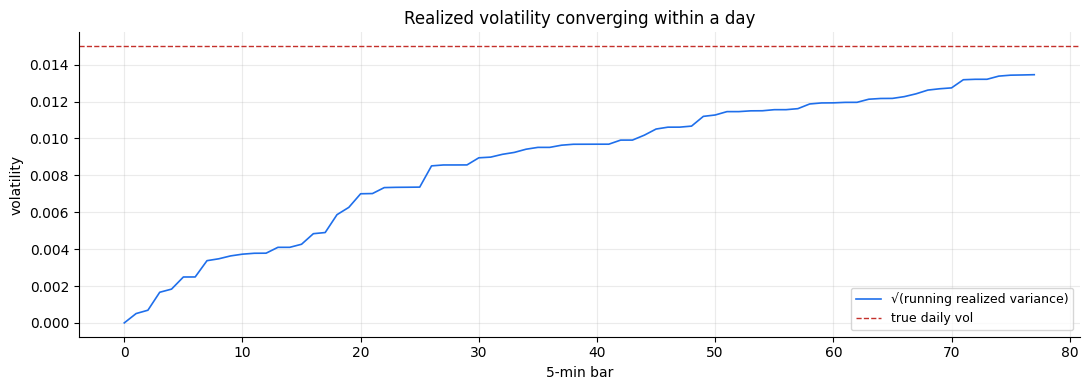

full-day realized vol = 0.0015  (true 0.015)


In [4]:
rng = np.random.default_rng(7)
true_daily_vol = 0.015
intraday = rng.normal(0, true_daily_vol / np.sqrt(78), size=78)  # 78 5-min bars
rv_running = np.array([realized_variance(intraday[:k]) for k in range(1, 79)])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.sqrt(rv_running), color='#1f6feb', lw=1.2, label='√(running realized variance)')
ax.axhline(true_daily_vol, color='#c4302b', lw=1.0, ls='--', label='true daily vol')
ax.set_title('Realized volatility converging within a day')
ax.set_ylabel('volatility'); ax.set_xlabel('5-min bar'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'full-day realized vol = {realized_volatility(intraday):.4f}  (true {true_daily_vol})')


## 3. Bipower variation & jumps

Realized variance (RV) absorbs jumps; **bipower variation** (BV) does not. The
gap ``RV − BV`` therefore estimates the jump contribution to total variation —
the basis of jump tests.


In [5]:
clean = rng.normal(0, 0.01, size=2000)
jumpy = clean.copy(); jumpy[[500, 1200, 1700]] += [0.08, -0.10, 0.06]

for name, r in [('no jumps', clean), ('with jumps', jumpy)]:
    rv = realized_variance(r); bv = bipower_variation(r)
    print(f'{name:>10}: RV={rv:.4e}  BV={bv:.4e}  jump share={max(rv-bv,0)/rv:.1%}')


  no jumps: RV=1.9574e-01  BV=1.9319e-01  jump share=1.3%
with jumps: RV=2.1336e-01  BV=1.9639e-01  jump share=8.0%


## 4. HAR-RV forecasting

Corsi's HAR-RV regresses today's realized variance on its **daily, weekly and
monthly** averages — a parsimonious way to capture volatility's long memory.
We fit it to a persistent realized-variance series and forecast 22 days ahead.


β = [ 0.      1.076  -0.1492  0.016 ]   R²=0.908   AIC=-21170.2


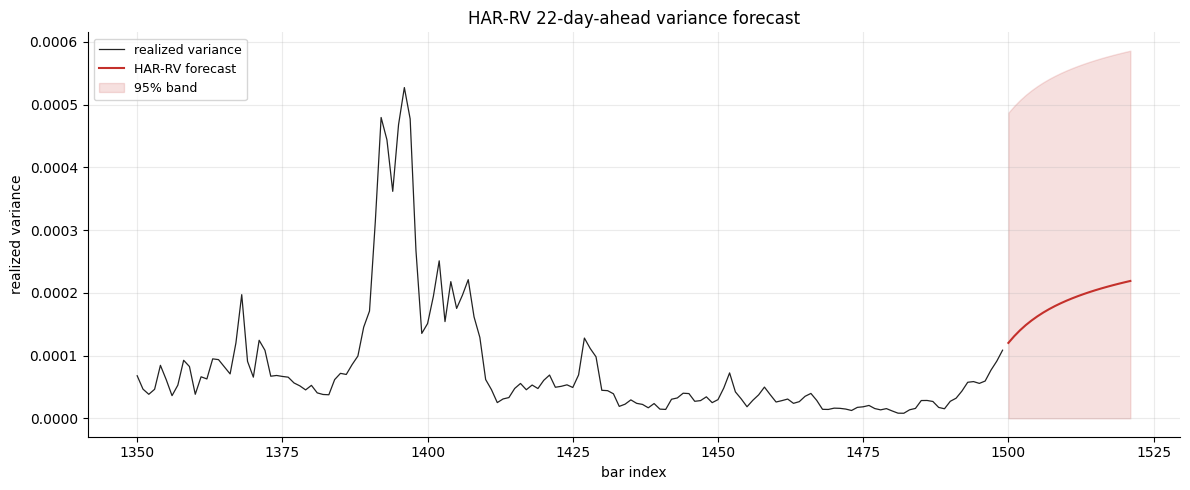

In [6]:
# A persistent daily realized-variance series (log-AR(1)).
n = 1500
log_rv = np.empty(n); log_rv[0] = np.log(1e-4)
for t in range(1, n):
    log_rv[t] = np.log(1e-4) + 0.96 * (log_rv[t-1] - np.log(1e-4)) + rng.normal(0, 0.35)
rv = np.exp(log_rv)

model = HARRV().fit(rv)
print(f'β = {model.beta.round(4)}   R²={model.r_squared:.3f}   AIC={model.aic:.1f}')

fc = model.forecast(22, alpha=0.05)
hist = np.arange(n)
fut = np.arange(n, n + 22)
fig, ax = plt.subplots()
ax.plot(hist[-150:], rv[-150:], color='#222', lw=0.9, label='realized variance')
ax.plot(fut, fc.mean, color='#c4302b', lw=1.5, label='HAR-RV forecast')
ax.fill_between(fut, fc.lower, fc.upper, color='#c4302b', alpha=0.15, label='95% band')
ax.set_title('HAR-RV 22-day-ahead variance forecast')
ax.set_ylabel('realized variance'); ax.set_xlabel('bar index'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **Benchmark against GARCH.** Fit `qufin.timeseries.GARCH` to the same
  returns and compare one-step volatility forecasts with
  `qufin.timeseries.forecast_eval` (Diebold-Mariano). HAR-RV and GARCH often
  combine well.
* **Feed vol-targeting.** Any of these estimators can drive the position
  scaling in `qufin.strategies.TimeSeriesMomentumStrategy` /
  `GARCHVolTargetStrategy`.
* **Trade the jump component.** ``RV − BV`` flags jump days; condition entries
  or hedges on it.
